# Patch success bbox geometry

Новый геометрический эксперимент по clean bbox до атаки: размер объекта и расстояния от патча до центра, ближнего края и дальнего края объекта.

In [1]:
from pathlib import Path
import sys

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import importlib
import matplotlib.pyplot as plt
import pandas as pd

from patch_success_analysis.notebook_setup import ensure_new_experiments_cwd, make_coco_people_patch_success_experiment
import patch_success_analysis.geometry_metrics as geometry_metrics

geometry_metrics = importlib.reload(geometry_metrics)

max_per_class = 3000  # None = all balanced cached examples.

cwd = ensure_new_experiments_cwd()
attack_config, config, exp = make_coco_people_patch_success_experiment()
cache = exp.build_or_load_cache(force=False)
examples = geometry_metrics.select_balanced_examples(cache, max_per_class=max_per_class)

print(f"cwd={cwd}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
print(f"examples={len(examples)} | success={sum(e.success for e in examples)} | fail={sum(not e.success for e in examples)}")


cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
attack cache key=e91cdfc4a2c4e20d
attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_e91cdfc4a2c4e20d.pkl
examples=5650 | success=3000 | fail=2650


In [2]:
geometry_df = geometry_metrics.geometry_frame(examples, imgsz=int(config.attack.imgsz))
display(geometry_df.head())
display(geometry_metrics.geometry_summary(geometry_df))
print(f"rows with geometry={len(geometry_df)}")


,path,success,drop,conf_clean,conf_patch,bbox_x1,bbox_y1,bbox_x2,bbox_y2,bbox_width,...,patch_x1,patch_y1,patch_x2,patch_y2,distance_to_object_center,distance_to_object_center_frac,distance_to_nearest_object_edge,distance_to_nearest_object_edge_frac,distance_to_farthest_object_edge,distance_to_farthest_object_edge_frac
0,../datasets/COCO_people/06356_train2017_image4...,True,0.402123,0.933572,0.531450,169.269257,56.565002,471.787872,617.203735,302.518616,...,0.0,0.0,160.0,160.0,351.914150,0.549866,9.269257,0.014483,664.895172,1.038899
1,../datasets/COCO_people/00972_train2017_image3...,True,0.636096,0.876672,0.240576,207.973633,38.973022,428.156555,608.600281,220.182922,...,0.0,0.0,160.0,160.0,340.744656,0.532414,47.973633,0.074959,632.954377,0.988991
2,../datasets/COCO_people/01552_train2017_image1...,True,0.876263,0.876263,0.000000,199.905624,38.225098,471.904053,596.331665,271.998428,...,0.0,0.0,160.0,160.0,348.981829,0.545284,39.905624,0.062353,648.218462,1.012841
3,../datasets/COCO_people/02665_train2017_image8...,True,0.369444,0.926853,0.557409,164.279510,32.714966,474.109283,599.790894,309.829773,...,0.0,0.0,160.0,160.0,336.198463,0.525310,4.279510,0.006687,652.307213,1.019230
4,../datasets/COCO_people/02406_train2017_image2...,True,0.937165,0.937165,0.000000,183.003021,39.457397,457.931793,605.615845,274.928772,...,0.0,0.0,160.0,160.0,341.538558,0.533654,23.003021,0.035942,647.382774,1.011536


bbox_area_frac                               bbox_sqrt_area_frac  \
                 count      mean       std    median               count   
success                                                                    
False             2513  0.468508  0.178066  0.463303                2513   
True              3000  0.420301  0.150926  0.394121                3000   

                                      bbox_width              ...  \
             mean       std    median      count        mean  ...   
success                                                       ...   
False    0.667487  0.151588  0.680664       2513  346.621186  ...   
True     0.636843  0.121397  0.627790       3000  309.160221  ...   

        distance_to_object_center             distance_to_nearest_object_edge  \
                              std      median                           count   
success                                                                         
False                   45.690898  341.276561                            2513   
True                    40.680194  340.431757                            3000   

                                        distance_to_farthest_object_edge  \
              mean        std    median                            count   
success                                                                    
False    30.496111  62.566249  0.000000                             2513   
True     30.186624  49.237036  7.695694                             3000   

                                            
               mean        std      median  
success                                     
False    665.128312  74.707044  671.134216  
True     653.986374  59.495822  654.133351  

[2 rows x 76 columns]

rows with geometry=5513


## Object Size

Основной размер объекта: bbox area fraction (`bbox_area / 640^2`). Слева bar chart mean +/- std, справа все значения: sampled scatter + boxplot.

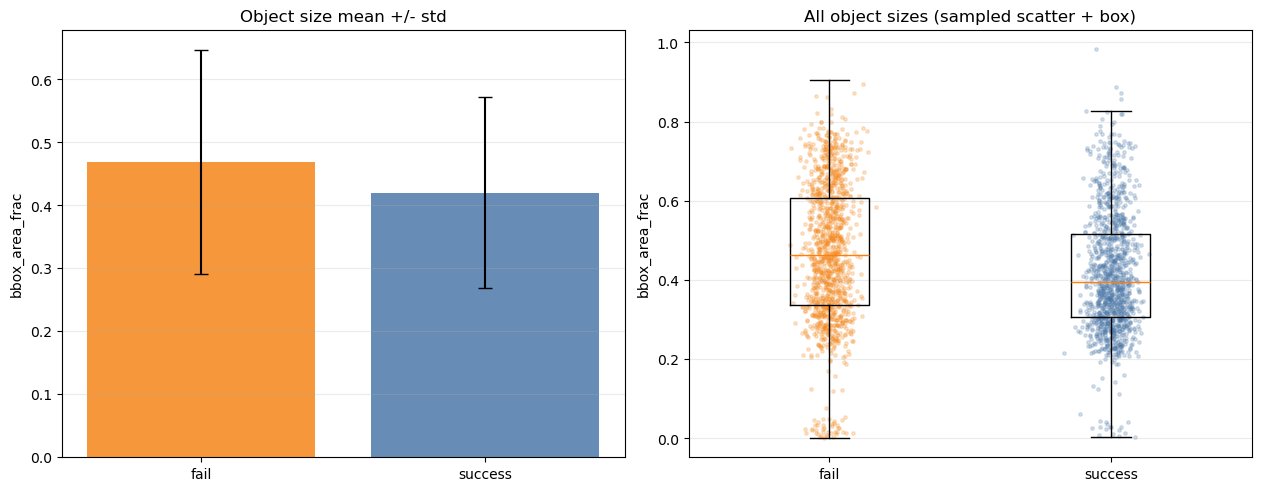

new_experiments/outputs/patch_success_analysis/figures/bbox_object_size_success_fail.png


In [3]:
fig = geometry_metrics.plot_object_size_summary(geometry_df, metric="bbox_area_frac")
object_size_fig_path = exp.figures_dir / "bbox_object_size_success_fail.png"
fig.savefig(object_size_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(object_size_fig_path)


## Patch-to-Object Distances

Distances are measured in the 640x640 letterboxed coordinate system:

- center: patch center to clean bbox center;
- nearest edge: minimum rectangle-to-rectangle distance, 0 if patch overlaps bbox;
- farthest edge: maximum distance from patch center to clean bbox corners.

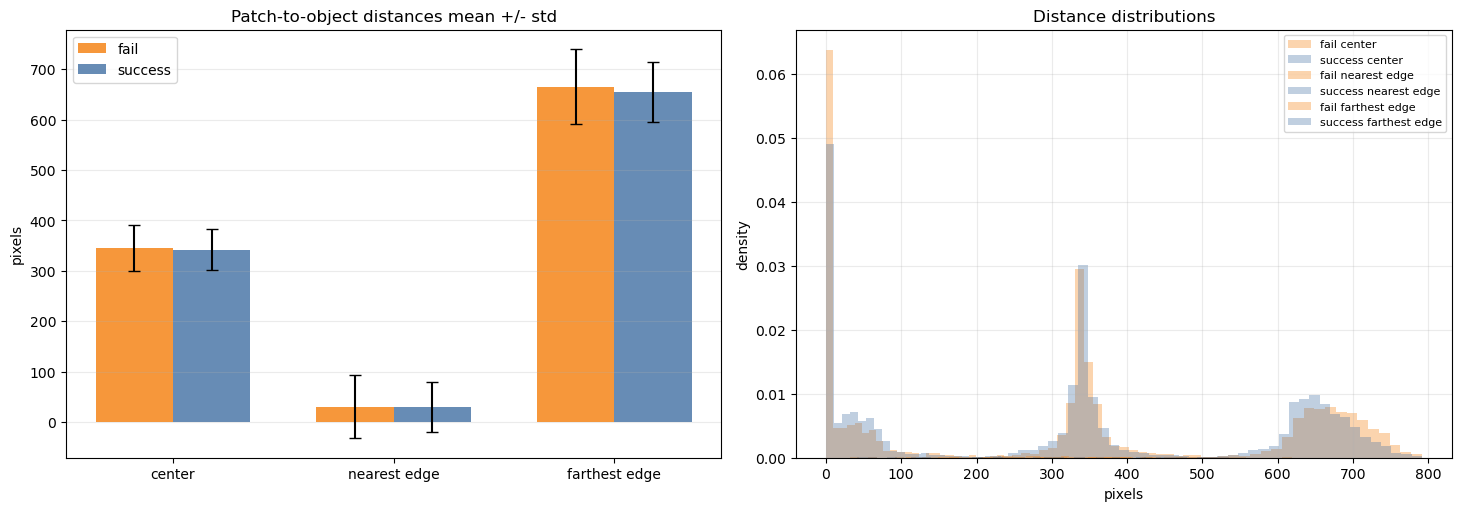

new_experiments/outputs/patch_success_analysis/figures/bbox_patch_object_distances_success_fail.png


In [4]:
fig = geometry_metrics.plot_geometry_distance_summary(geometry_df)
distance_fig_path = exp.figures_dir / "bbox_patch_object_distances_success_fail.png"
fig.savefig(distance_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(distance_fig_path)


In [5]:
distance_cols = [
    "distance_to_object_center",
    "distance_to_nearest_object_edge",
    "distance_to_farthest_object_edge",
]
display(
    geometry_df.groupby("success")[distance_cols + ["bbox_area_frac", "bbox_sqrt_area_frac"]]
    .agg(["mean", "std", "median"])
    .rename(index={False: "fail", True: "success"})
)


distance_to_object_center                         \
                             mean        std      median   
success                                                    
fail                   346.223584  45.690898  341.276561   
success                341.618631  40.680194  340.431757   

        distance_to_nearest_object_edge                       \
                                   mean        std    median   
success                                                        
fail                          30.496111  62.566249  0.000000   
success                       30.186624  49.237036  7.695694   

        distance_to_farthest_object_edge                         \
                                    mean        std      median   
success                                                           
fail                          665.128312  74.707044  671.134216   
success                       653.986374  59.495822  654.133351   

        bbox_area_frac                     bbox_sqrt_area_frac            \
                  mean       std    median                mean       std   
success                                                                    
fail          0.468508  0.178066  0.463303            0.667487  0.151588   
success       0.420301  0.150926  0.394121            0.636843  0.121397   

                   
           median  
success            
fail     0.680664  
success  0.627790